# Hindcast Blocking Frequency

Computes and plots blocking frequency (Davini et al. 2012) from CESM2 S2S hindcasts.

Data: `/glade/campaign/cesm/development/cross-wg/S2S/CESM2/S2SHINDCASTS/Z3/`  
Structure: `{year}/{month:02d}/Z3_cesm2cam6v2_{DD}{mon}{YYYY}00z_d01_d46_m{MM}.nc`

**Workflow**
1. (Once) Build Z500 cache — one file per ensemble member, dims `(start_date, lead_day, lat, lon)`
2. Compute blocking frequency per lead day, per ensemble member
3. Plot ensemble mean ± 1 std for selected lead days

## Imports

In [1]:
import importlib
import pandas as pd
import hindcast_blocking_utils as hb_utils
import hindcast_blocking_figs  as hb_figs

%load_ext autoreload
%autoreload 2

In [2]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [3]:
# NOTE: This cluster is only used for block_freq_all_leaddays.
# build_z500_cache uses ThreadPoolExecutor internally and ignores this cluster.
#
# On Derecho, workers contact the scheduler via InfiniBand (ib0).
# "ext" is the external/login-node interface and is NOT reachable from compute nodes.
cluster = PBSCluster(
    account="P03010039",
    interface="ext",            # InfiniBand — required for htc→main connectivity
    walltime="04:00:00",
    queue="main",
    cores=4,
    memory="32GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs",
    resource_spec="select=1:ncpus=4:mem=32GB",
)

print(cluster.job_script())   # inspect the generated PBS script before scaling

cluster.scale(jobs=4)
client = Client(cluster)

# Wait up to 120 s for at least one worker — surfaces connection problems quickly.
try:
    client.wait_for_workers(1, timeout=120)
    print(f"Workers connected: {len(client.scheduler_info()['workers'])}")
except Exception as e:
    print(f"WARNING: no workers connected after 120s — {e}")
    print("Check logs in /glade/derecho/scratch/rneale/dask-logs/")

client

#!/usr/bin/env bash

#PBS -N dask-worker
#PBS -q main
#PBS -A P03010039
#PBS -l select=1:ncpus=4:mem=32GB
#PBS -l walltime=04:00:00
#PBS -e /glade/derecho/scratch/rneale/dask-logs/
#PBS -o /glade/derecho/scratch/rneale/dask-logs/

/glade/u/apps/opt/miniforge/envs/npl-2026a/bin/python -m distributed.cli.dask_worker tcp://128.117.208.189:35885 --name dummy-name --nthreads 1 --memory-limit 7.45GiB --nworkers 4 --nanny --death-timeout 60 --local-directory /glade/derecho/scratch/rneale/dask-temp --interface ext

Workers connected: 3


<Client: 'tcp://128.117.208.189:35885' processes=3 threads=3, memory=22.35 GiB>

---
## TOP LEVEL OPTIONS

In [16]:
# ── Data & cache directories ───────────────────────────────────────────────
DATA_DIR       = hb_utils.DATA_DIR     # hindcast Z3 files
CACHE_DIR      = hb_utils.CACHE_DIR    # Z500 + blocking freq cache
ERA5_PATH      = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/z500_era5_dmean_1x1.nc'
ERA5_VERIFY_DIR= hb_utils.ERA5_VERIFY_DIR   # per-year ERA5 files for verification

# ── Year / month selection for cache build ────────────────────────────────
# None = all available;  e.g. years=list(range(1999,2020)), months=[12,1,2]
YEARS  = list(range(2021,2022))
print(YEARS)
MONTHS = None

# ── Season for blocking frequency ─────────────────────────────────────────
# 'DJF' | 'MAM' | 'JJA' | 'SON' | None (all months)
BLOCK_SEASON = 'DJF'

# ── Number of lead days to process (max 46) ───────────────────────────────
N_LEADDAYS = 20

# ── Blocking diagnostics ──────────────────────────────────────────────────
# '1D'   – 1D blocking frequency [0–1]
# '2D'   – 2D blocking frequency [0–1]   (kept as %; retained separately below)
# 'GHGS' – mean south Z500 gradient strength (m / degree-lat)
# 'GHGN' – mean north Z500 gradient strength (m / degree-lat)
BLOCK_DIAG_SET = ['GHGS', 'GHGN']

# ── Lead days to show in figures ──────────────────────────────────────────
# A manageable subset; set None to plot all N_LEADDAYS
PLOT_LEAD_DAYS = [1, 2, 3, 4, 5, 10, 15, 20]

# ── File I/O options for Z500 cache ───────────────────────────────────────
# overwrite=False  skip existing cache files (fast re-run)
# overwrite=True   rebuild from raw data
OVERWRITE_Z500  = False
OVERWRITE_BLOCK = False

print(f'Season : {BLOCK_SEASON}  |  n_leaddays : {N_LEADDAYS}')
print(f'Cache  : {CACHE_DIR}')

[2021]
Season : DJF  |  n_leaddays : 20
Cache  : /glade/work/rneale/python-netcdf/hindcast_blocking


## (Optional) Dask cluster — useful for large parallel builds

---
## 1. File inventory

In [17]:
file_df = hb_utils.list_hindcast_files(DATA_DIR, years=YEARS, months=MONTHS)
print(file_df.head(10))

list_hindcast_files: 1519 files  | 1 years  | 72 start dates  | 22 members
   year  month  start_str  member  \
0  2021      1  04jan2021       0   
1  2021      1  04jan2021       1   
2  2021      1  04jan2021       2   
3  2021      1  04jan2021       3   
4  2021      1  04jan2021       4   
5  2021      1  04jan2021       5   
6  2021      1  04jan2021       6   
7  2021      1  04jan2021       7   
8  2021      1  04jan2021       8   
9  2021      1  04jan2021       9   

                                                path  
0  /glade/campaign/cesm/development/cross-wg/S2S/...  
1  /glade/campaign/cesm/development/cross-wg/S2S/...  
2  /glade/campaign/cesm/development/cross-wg/S2S/...  
3  /glade/campaign/cesm/development/cross-wg/S2S/...  
4  /glade/campaign/cesm/development/cross-wg/S2S/...  
5  /glade/campaign/cesm/development/cross-wg/S2S/...  
6  /glade/campaign/cesm/development/cross-wg/S2S/...  
7  /glade/campaign/cesm/development/cross-wg/S2S/...  
8  /glade/campaign/ces

---
## 2. Build Z500 cache  (skip if already done)

In [18]:
hb_utils.z500_cache_status(cache_dir=CACHE_DIR)

Z500 cache: 189 file(s) in /glade/work/rneale/python-netcdf/hindcast_blocking
  members: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]   years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
  m00:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m01:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m02:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m03:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m04:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m05:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m06:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m07:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m08:  [2015, 2016, 2017, 2019, 2020, 2021, 2022]  MISSING [2018]
  m09:  [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]  OK
  m10:  [2015, 2016, 2017, 2018, 2019, 202

In [19]:
# Each source file is opened ONCE and all lead days extracted together.
# Members processed in parallel (n_workers threads).
# ~46× fewer file I/Os vs the previous per-lead-day loop.
# Output: z500_hindcast_m{MM:02d}_{YYYY1}-{YYYY2}.nc  (one file per member)

hb_utils.build_z500_cache(
    data_dir   = DATA_DIR,
    cache_dir  = CACHE_DIR,
    years      = YEARS,
    months     = MONTHS,
    n_leaddays = N_LEADDAYS,
    overwrite  = OVERWRITE_Z500,
    n_workers  = 8,             # threads for parallel member processing
)

list_hindcast_files: 1519 files  | 1 years  | 72 start dates  | 22 members

build_z500_cache: 1 year(s)  →  22 output files  (n_workers=8)
  2021: 22 members  (m00–m21)

  year 2021: 22 members  72 start dates  (04jan2021 → 27dec2021)
    m00: cache exists, skipping → z500_hindcast_m00_2021.nc
    m01: cache exists, skipping → z500_hindcast_m01_2021.nc
    m02: cache exists, skipping → z500_hindcast_m02_2021.nc
    m04: cache exists, skipping → z500_hindcast_m04_2021.nc
    m03: cache exists, skipping → z500_hindcast_m03_2021.nc
    m05: cache exists, skipping → z500_hindcast_m05_2021.nc
    m08: cache exists, skipping → z500_hindcast_m08_2021.nc
    m06: cache exists, skipping → z500_hindcast_m06_2021.nc
    m07: cache exists, skipping → z500_hindcast_m07_2021.nc
    m09: cache exists, skipping → z500_hindcast_m09_2021.nc
    m13: cache exists, skipping → z500_hindcast_m13_2021.nc
    m10: cache exists, skipping → z500_hindcast_m10_2021.nc
    m11: cache exists, skipping → z500_hindca

In [20]:
# Returns {lead_day: DataArray(member, lon)}  — frequency per member
block_freq_1d = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = '1D',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = list(range(22)),   # m00–m21: all 5 years available
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

block_freq_all_leaddays: block_diag=1D  season=DJF  n_leaddays=20  years=[2021]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

  lead day   1: reading block cache
  lead day   2: reading block cache
  lead day   3: reading block cache
  lead day   4: reading block cache
  lead day   5: reading block cache
  lead day   6: reading block cache
  lead day   7: reading block cache
  lead day   8: reading block cache
  lead day   9: reading block cache
  lead day  10: reading block cache
  lead day  11: reading block cache
  lead day  12: reading block cache
  lead day  13: reading block cache
  lead day  14: reading block cache
  lead day  15: reading block cache
  lead day  16: reading block cache
  lead day  17: reading block cache
  lead day  18: reading block cache
  lead day  19: reading block cache
  lead day  20: reading block cache

block_freq_all_leaddays: done.


---
## 3a. Compute 1D blocking frequency – all lead days

## 3b. Compute 2D blocking frequency – all lead days

In [21]:
# Returns {lead_day: DataArray(member, lat, lon)}
block_freq_2d = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = '2D',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = list(range(22)),   # m00–m21: all 5 years available
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

block_freq_all_leaddays: block_diag=2D  season=DJF  n_leaddays=20  years=[2021]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

  lead day   1: reading block cache
  lead day   2: reading block cache
  lead day   3: reading block cache
  lead day   4: reading block cache
  lead day   5: reading block cache
  lead day   6: reading block cache
  lead day   7: reading block cache
  lead day   8: reading block cache
  lead day   9: reading block cache
  lead day  10: reading block cache
  lead day  11: reading block cache
  lead day  12: reading block cache
  lead day  13: reading block cache
  lead day  14: reading block cache
  lead day  15: reading block cache
  lead day  16: reading block cache
  lead day  17: reading block cache
  lead day  18: reading block cache
  lead day  19: reading block cache
  lead day  20: reading block cache

block_freq_all_leaddays: done.


## 3c. Compute GHGS (south gradient strength) – all lead days

In [22]:
# Returns {lead_day: DataArray(member, lon)}  — mean south gradient (m / degree-lat)
# Positive GHGS = normal equatorward Z500 decrease; blocking criterion: GHGS > 0
block_ghgs = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = 'GHGS',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = list(range(22)),
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

block_freq_all_leaddays: block_diag=GHGS  season=DJF  n_leaddays=20  years=[2021]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

  lead day   1: reading block cache
  lead day   2: reading block cache
  lead day   3: reading block cache
  lead day   4: reading block cache
  lead day   5: reading block cache
  lead day   6: reading block cache
  lead day   7: reading block cache
  lead day   8: reading block cache
  lead day   9: reading block cache
  lead day  10: reading block cache
  lead day  11: reading block cache
  lead day  12: reading block cache
  lead day  13: reading block cache
  lead day  14: reading block cache
  lead day  15: reading block cache
  lead day  16: reading block cache
  lead day  17: reading block cache
  lead day  18: reading block cache
  lead day  19: reading block cache
  lead day  20: reading block cache

block_freq_all_leaddays: done.


## 3d. Compute GHGN (north gradient strength) – all lead days

In [23]:
# Returns {lead_day: DataArray(member, lon)}  — mean north gradient (m / degree-lat)
# Negative GHGN = reversed poleward Z500 gradient; blocking criterion: GHGN < -5
block_ghgn = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = 'GHGN',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = list(range(22)),
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

block_freq_all_leaddays: block_diag=GHGN  season=DJF  n_leaddays=20  years=[2021]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

  lead day   1: reading block cache
  lead day   2: reading block cache
  lead day   3: reading block cache
  lead day   4: reading block cache
  lead day   5: reading block cache
  lead day   6: reading block cache
  lead day   7: reading block cache
  lead day   8: reading block cache
  lead day   9: reading block cache
  lead day  10: reading block cache
  lead day  11: reading block cache
  lead day  12: reading block cache
  lead day  13: reading block cache
  lead day  14: reading block cache
  lead day  15: reading block cache
  lead day  16: reading block cache
  lead day  17: reading block cache
  lead day  18: reading block cache
  lead day  19: reading block cache
  lead day  20: reading block cache

block_freq_all_leaddays: done.


---
## 5b. Plot GHGS gradient – longitude lines by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_ghgs_hindcast_DJF_2021.png
block_plot_1d_gradient (GHGS): done in 0.2s


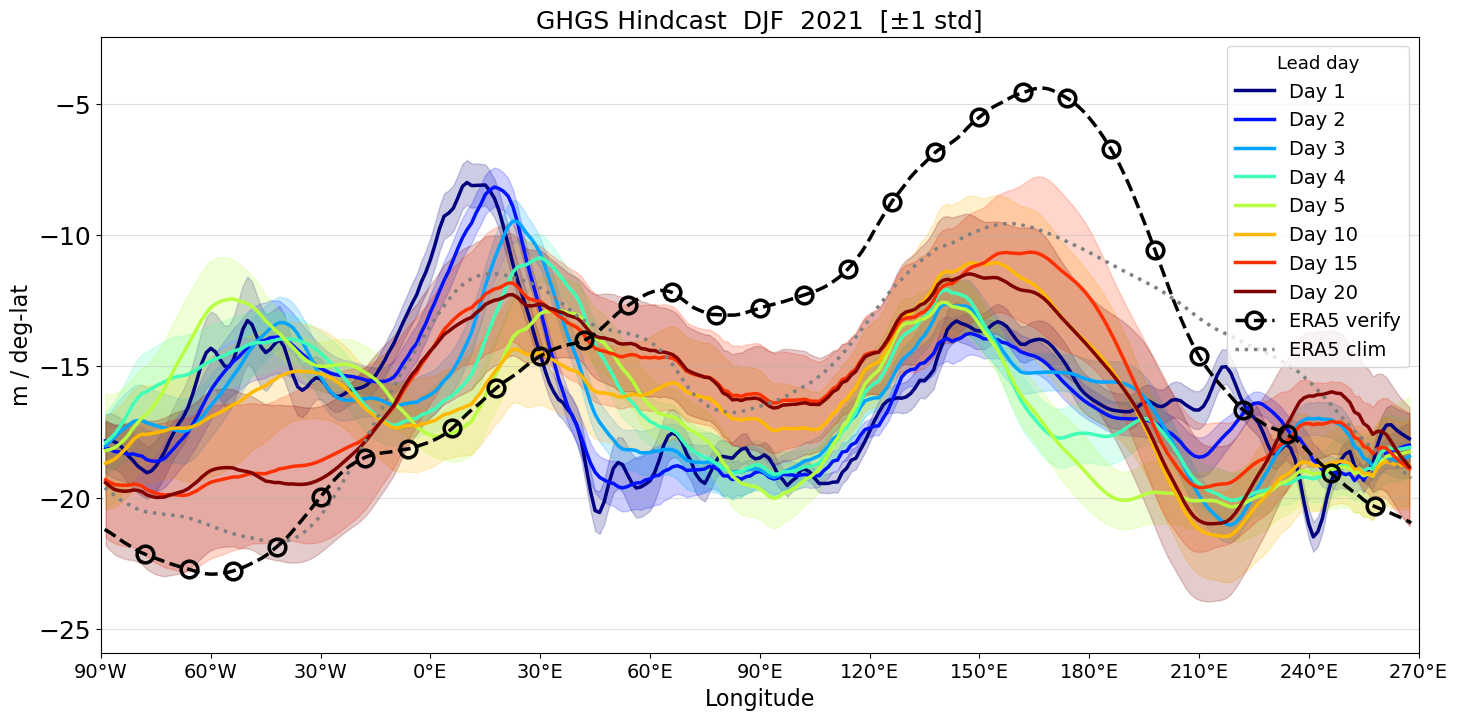

In [24]:
hb_figs.block_plot_1d_gradient(
    block_ghgs,
    diag_name      = 'GHGS',
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = YEARS,
    era5_clim_da   = era5_clim_ghgs,
    era5_verify_da = era5_verify_ghgs,
    fig_out        = True,
)

## 5c. Plot GHGN gradient – longitude lines by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_ghgn_hindcast_DJF_2021.png
block_plot_1d_gradient (GHGN): done in 0.2s


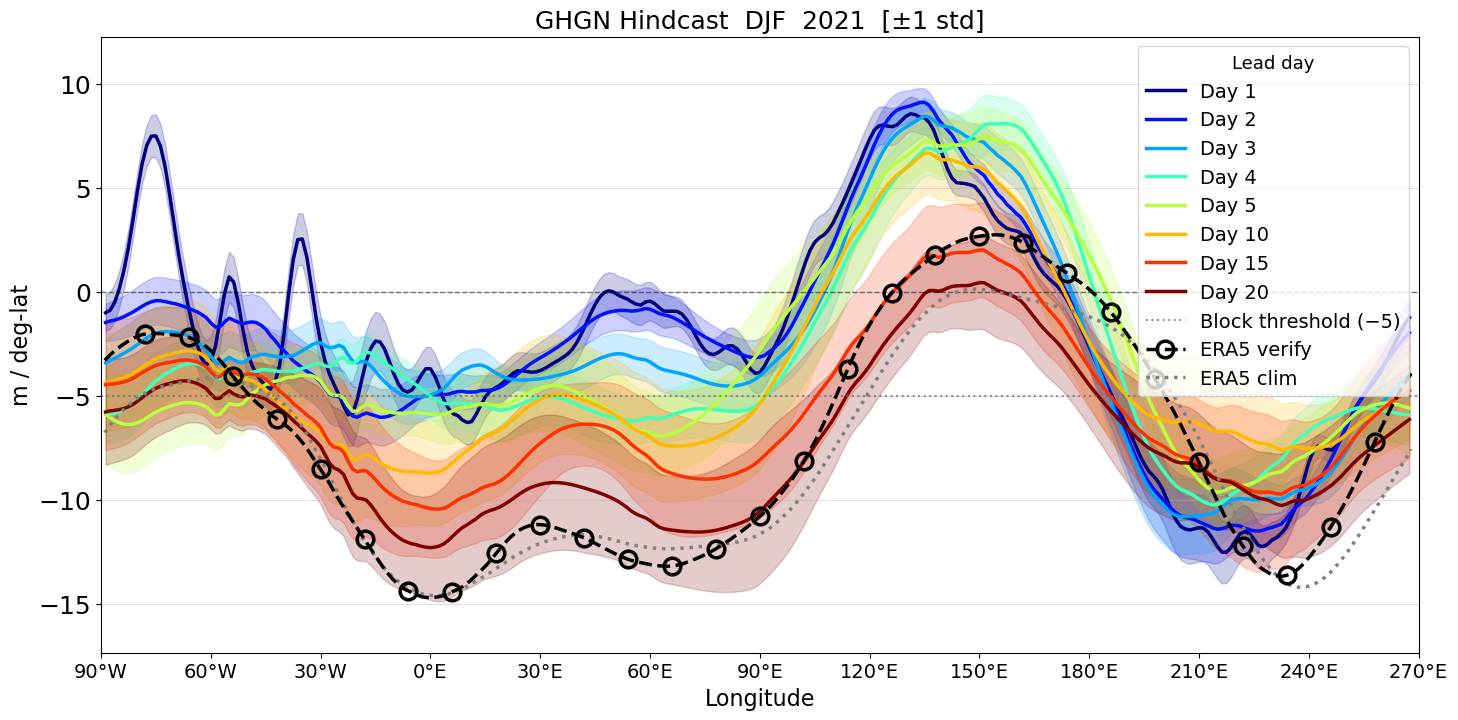

In [25]:
hb_figs.block_plot_1d_gradient(
    block_ghgn,
    diag_name      = 'GHGN',
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = YEARS,
    era5_clim_da   = era5_clim_ghgn,
    era5_verify_da = era5_verify_ghgn,
    fig_out        = True,
)


## 4. Plot 1D blocking frequency – lines coloured by lead day

In [26]:
# ERA5 full-season climatology (1979–2005) — all days in the season, no start-date filter.
era5_clim_1d = hb_utils.era5_season_clim_1d(ERA5_PATH, season=BLOCK_SEASON)
era5_clim_2d = hb_utils.era5_season_clim_2d(ERA5_PATH, season=BLOCK_SEASON)

# ERA5 verification — all season days from the hindcast year(s), per-year files.
# This is the single observed truth line to compare against all hindcast lead days.
era5_verify_1d = hb_utils.era5_verify_freq_1d(ERA5_VERIFY_DIR, YEARS, season=BLOCK_SEASON)
era5_verify_2d = hb_utils.era5_verify_freq_2d(ERA5_VERIFY_DIR, YEARS, season=BLOCK_SEASON)

# ERA5 gradient climatology and verification (m / degree-lat)
era5_clim_ghgs   = hb_utils.era5_season_clim_gradient(ERA5_PATH, season=BLOCK_SEASON, diag='GHGS')
era5_clim_ghgn   = hb_utils.era5_season_clim_gradient(ERA5_PATH, season=BLOCK_SEASON, diag='GHGN')
era5_verify_ghgs = hb_utils.era5_verify_gradient(ERA5_VERIFY_DIR, YEARS, season=BLOCK_SEASON, diag='GHGS')
era5_verify_ghgn = hb_utils.era5_verify_gradient(ERA5_VERIFY_DIR, YEARS, season=BLOCK_SEASON, diag='GHGN')

era5_season_clim_1d: 2437 days  mean blocking 10.7%
era5_season_clim_2d: 2437 days  mean blocking 5.1%
era5_verify_freq_1d: 90 days  mean blocking 5.5%
era5_verify_freq_2d: 90 days  mean blocking 3.5%
era5_season_clim_gradient (GHGS): 2437 days  mean -15.02 m/deg
era5_season_clim_gradient (GHGN): 2437 days  mean -8.08 m/deg
era5_verify_gradient (GHGS): 90 days  mean -16.42 m/deg
era5_verify_gradient (GHGN): 90 days  mean -3.72 m/deg


  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_1d_hindcast_DJF_2021.png
block_plot_1d_hindcast: done in 0.4s


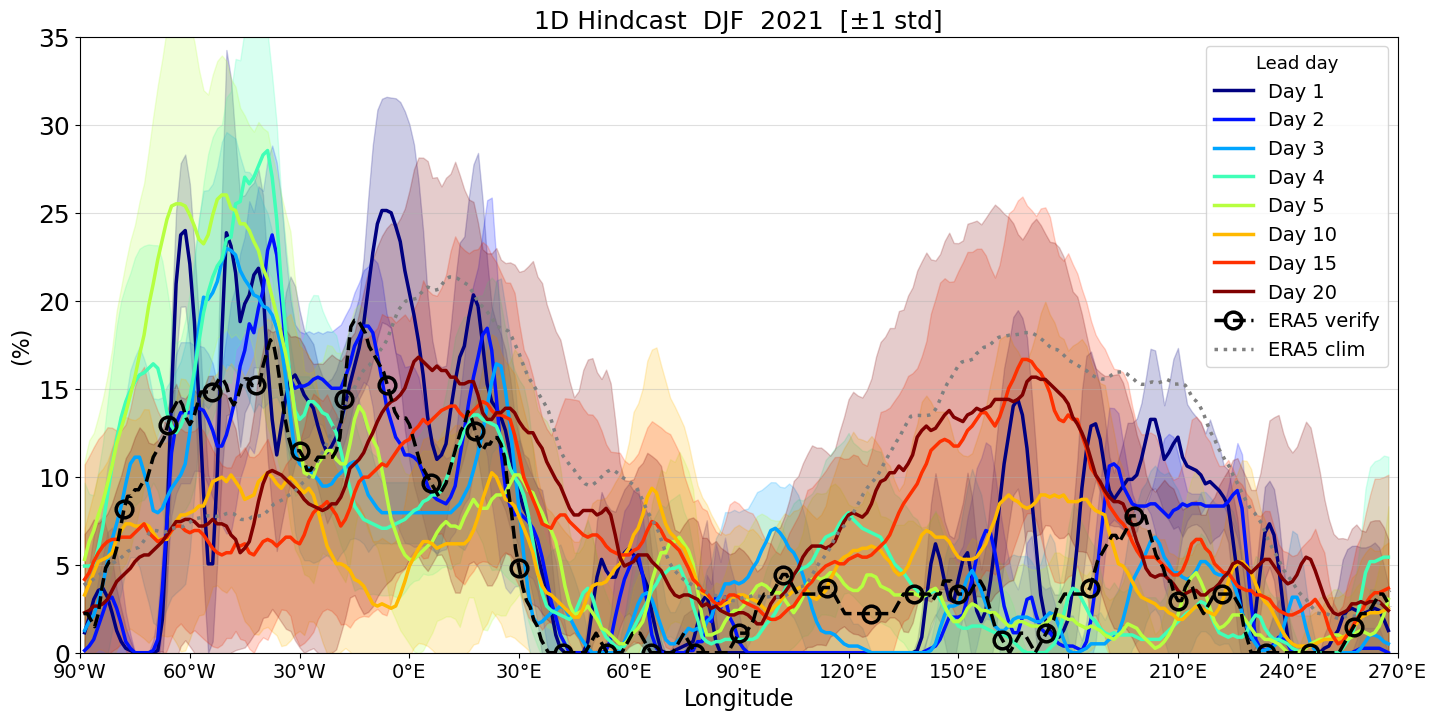

In [27]:
# Hindcast lines (mean ± 1 std shading, coloured by lead day)
# ERA5 verify: single black dashed line — observed DJF blocking in the hindcast year(s)
# ERA5 clim:   single mid-gray dotted line — 1979–2005 DJF climatology
hb_figs.block_plot_1d_hindcast(
    block_freq_1d,
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = YEARS,
    era5_verify_da = era5_verify_1d,
    era5_clim_da   = era5_clim_1d,
    fig_out        = True,
)

### 1D blocking – min/max spread

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_1d_hindcast_mmspread_DJF_2021.png
block_plot_1d_hindcast: done in 0.3s


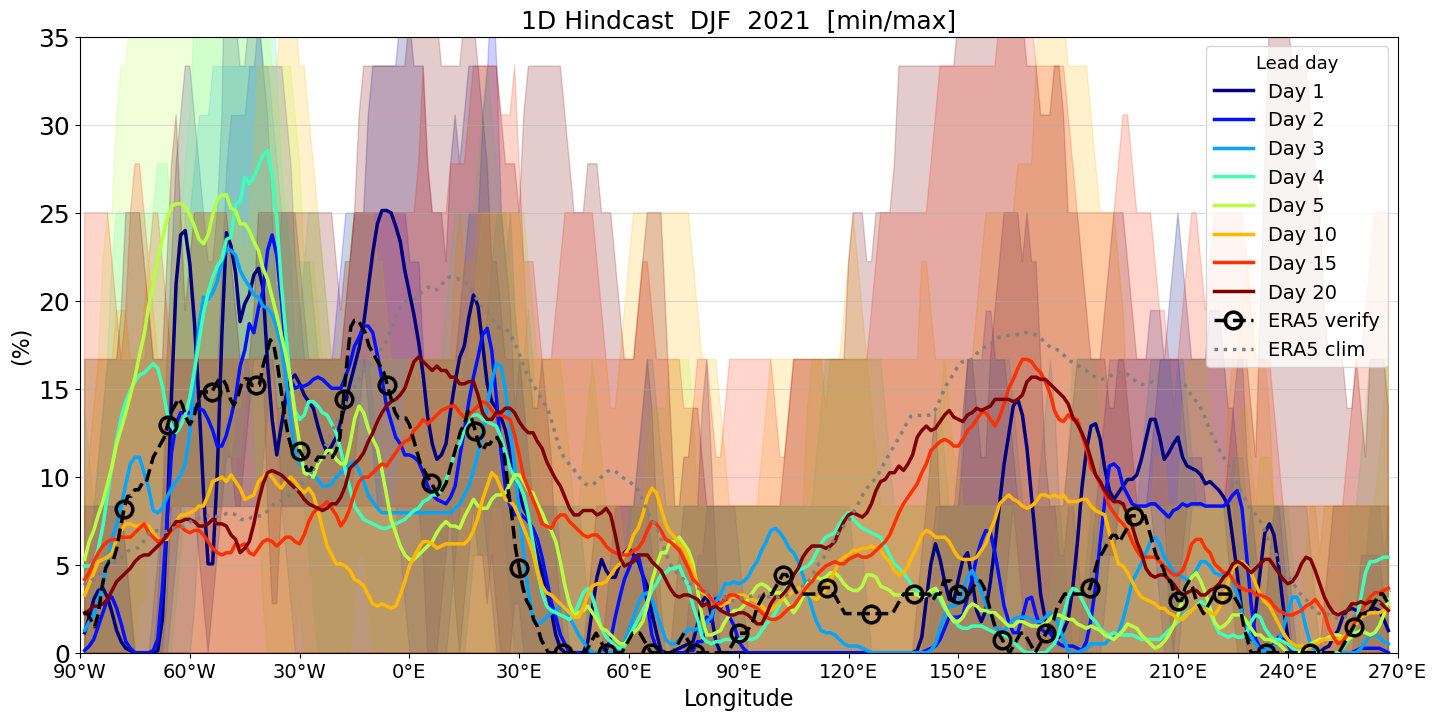

In [28]:
hb_figs.block_plot_1d_hindcast(
    block_freq_1d,
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = 'mm',
    season         = BLOCK_SEASON,
    years          = YEARS,
    era5_verify_da = era5_verify_1d,
    era5_clim_da   = era5_clim_1d,
    fig_out        = True,
    fig_name       = 'block_1d_hindcast_mmspread',
)

---
## 5. Plot 2D blocking frequency – polar map panels by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_2d_hindcast_DJF_2021.png


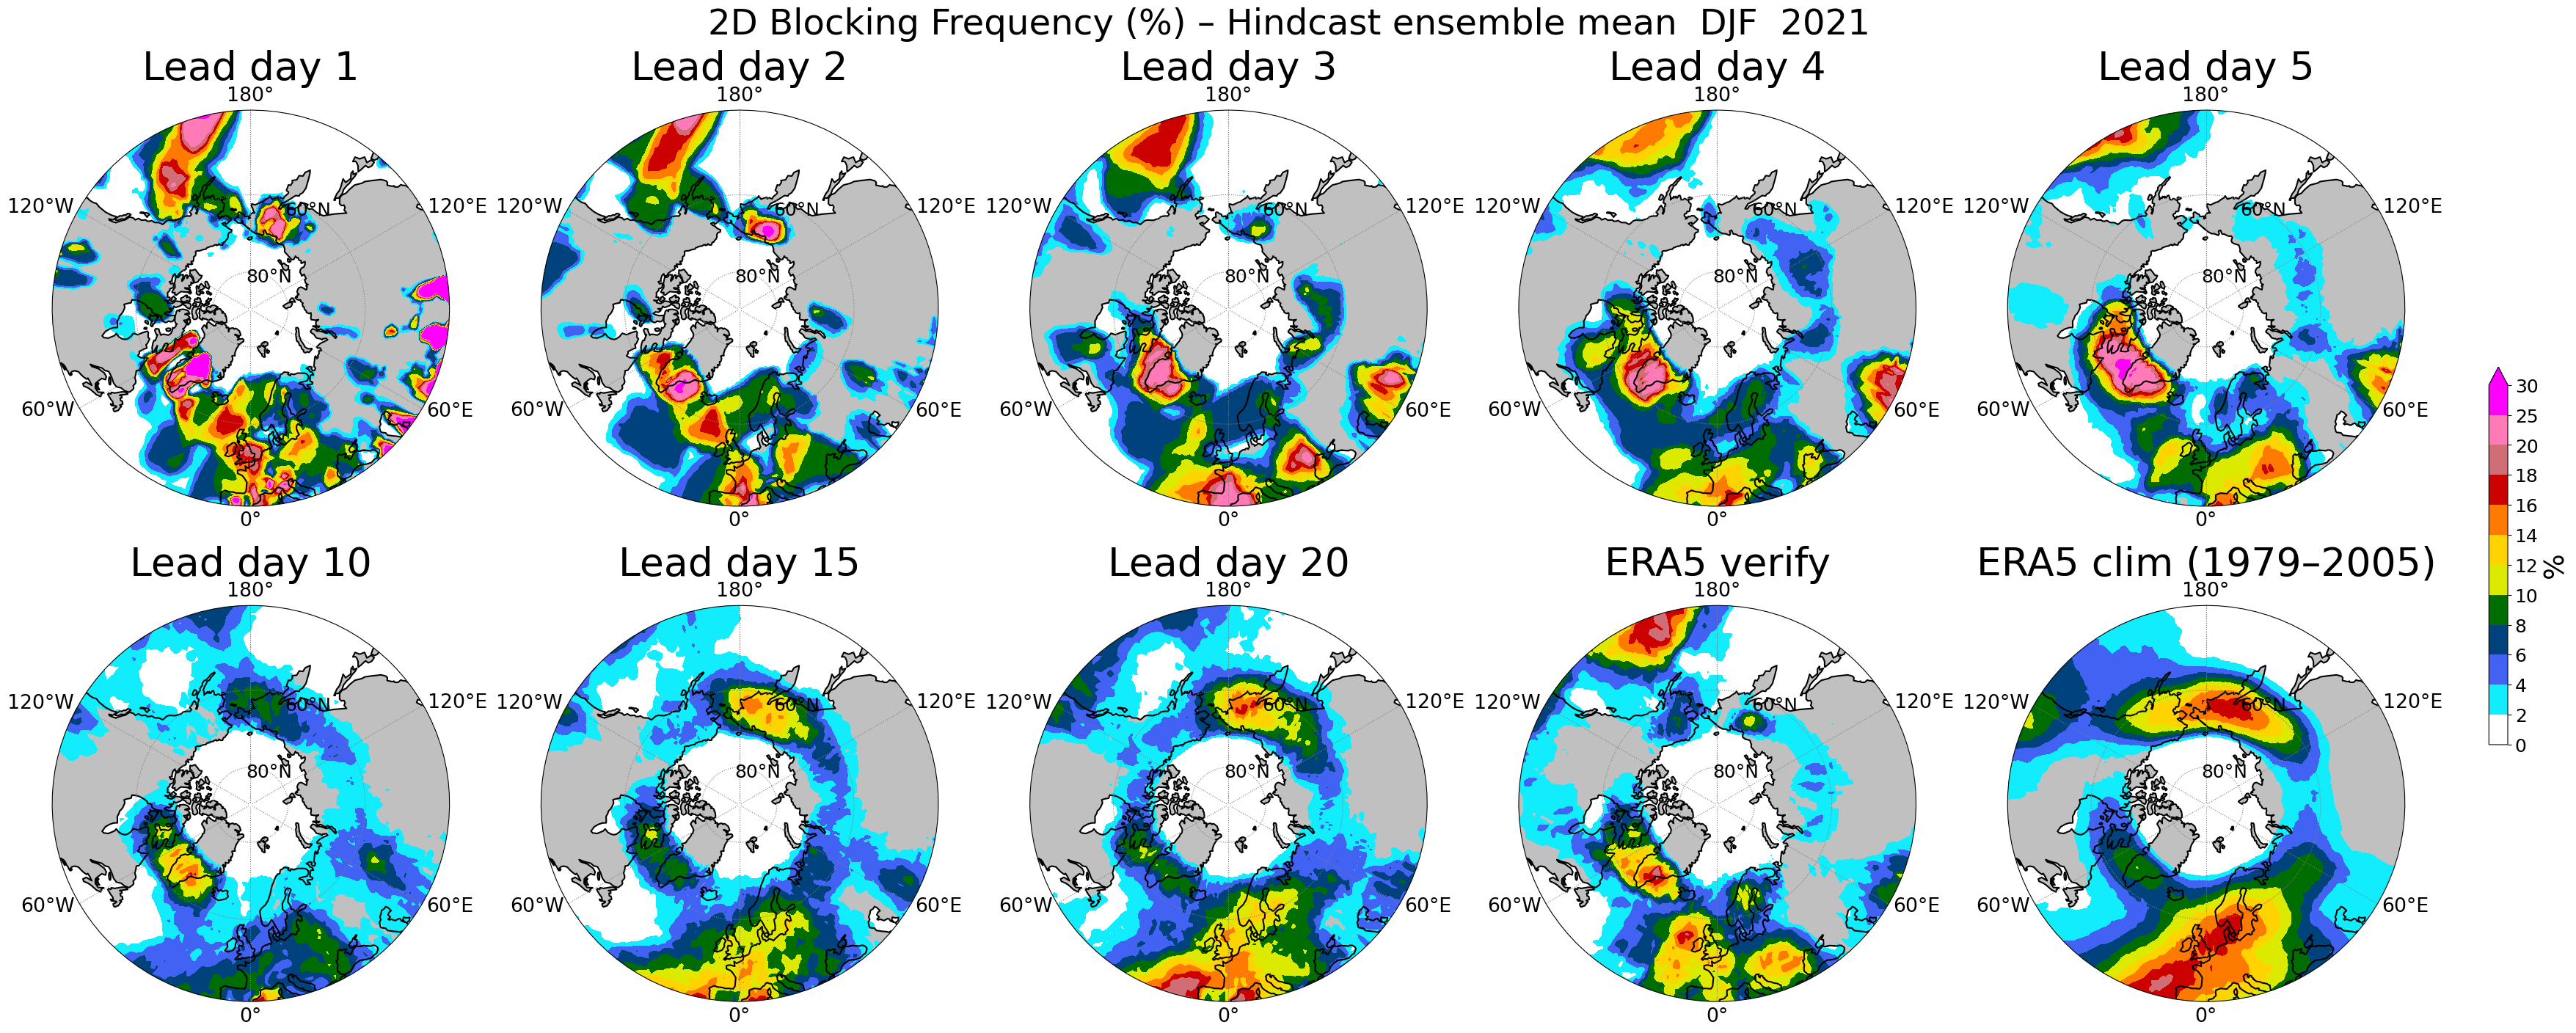

In [29]:
hb_figs.block_plot_2d_hindcast(
    block_freq_2d,
    lead_days      = PLOT_LEAD_DAYS,
    season         = BLOCK_SEASON,
    years          = YEARS,
    era5_verify_da = era5_verify_2d,
    era5_clim_da   = era5_clim_2d,
    max_cols       = 5,
    fig_out        = True,
)

---
## 6. Blocking frequency vs lead day (evolution plot)

Shows how the longitudinally-averaged blocking frequency evolves with forecast length.

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_evolution_hindcast_DJF_2021.png
block_plot_evolution: done in 0.1s
  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_evolution_hindcast_EUR_DJF_2021.png
block_plot_evolution: done in 0.1s


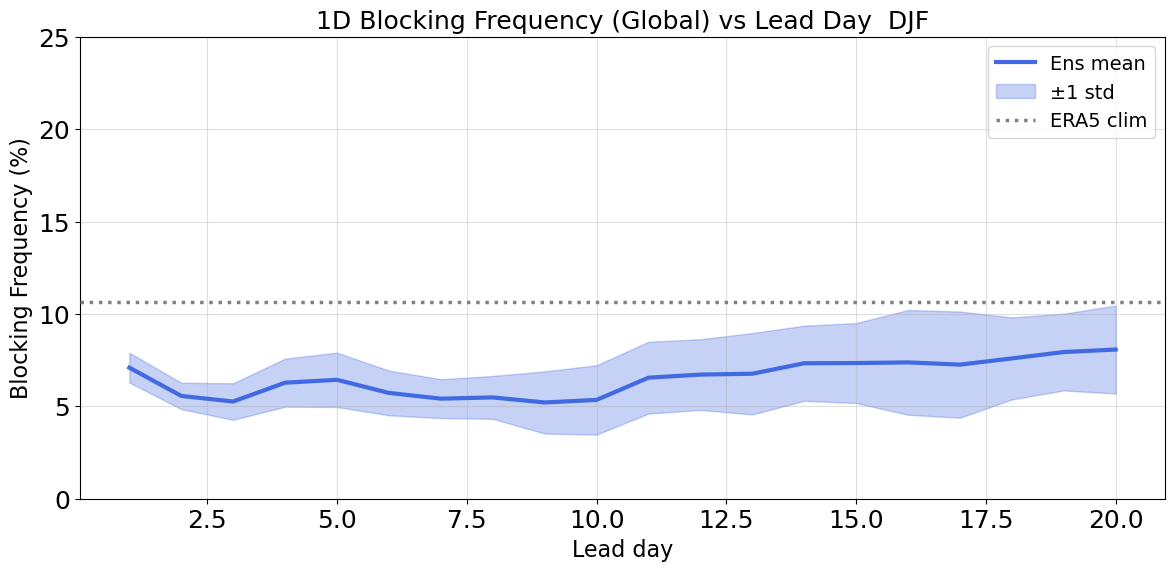

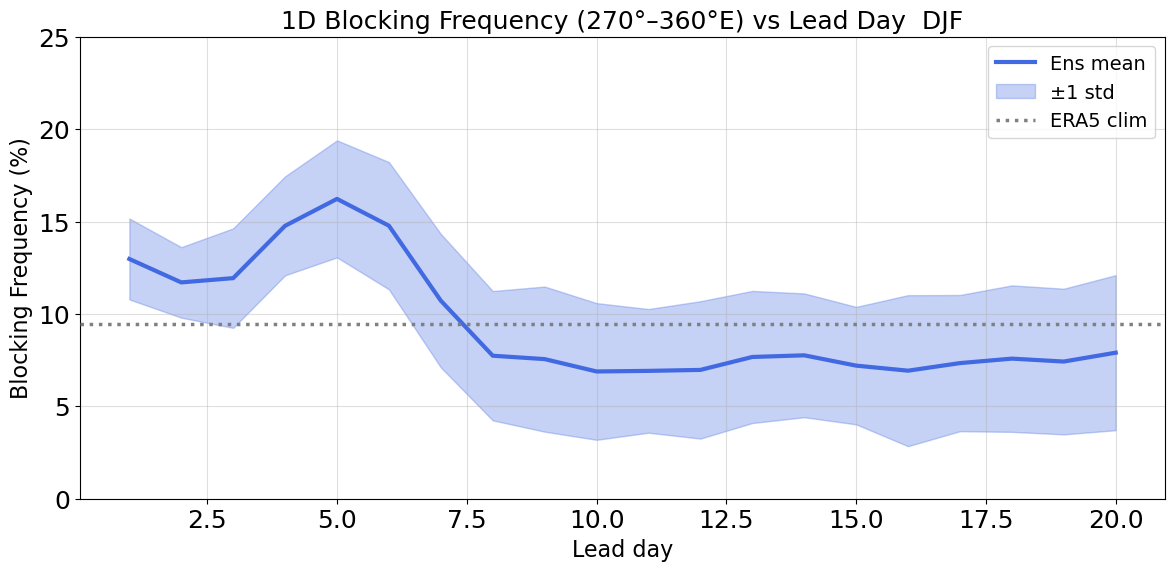

In [30]:
# Global average
hb_figs.block_plot_evolution(
    block_freq_1d,
    lon_range    = (0., 360.),
    season       = BLOCK_SEASON,
    years        = YEARS,
    era5_clim_da = era5_clim_1d,
    fig_out      = True,
)

# European sector
hb_figs.block_plot_evolution(
    block_freq_1d,
    lon_range    = (270., 360.),
    season       = BLOCK_SEASON,
    years        = YEARS,
    era5_clim_da = era5_clim_1d,
    fig_out      = True,
    fig_name     = 'block_evolution_hindcast_EUR',
)